In [3]:
import os
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, AIMessage

load_dotenv()
groq_api_key = os.getenv("GROG_API_KEY")
groq_api_key

C:\Users\ybalasaraswa\OneDrive - OpenText\Desktop\deep learning\LangChain\.myvenv\Lib\site-packages\langchain_core\_api\deprecation.py:26: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1
C:\Users\ybalasaraswa\OneDrive - OpenText\Desktop\deep learning\LangChain\.myvenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'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'

Now lets create an agent using the groq chat model without any tools

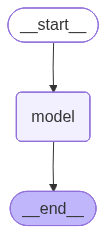

In [4]:
from langchain.agents import create_agent

agent = create_agent(
    model = ChatGroq(api_key=groq_api_key, model="openai/gpt-oss-120b"),
    tools=[],
    system_prompt="You are a helpful assistant."
)
agent

Now lets create a simple function/tool to give agent

In [5]:
import requests
def get_current_weather(location: str) -> str:
    api_key = os.getenv("OPEN_WEATHER_API")
    if not api_key:
        raise RuntimeError("OPEN_WEATHER_API is not set in environment variables")

    base_url = "https://api.openweathermap.org/data/2.5/weather"
    params = {
        "q": location,
        "appid": api_key,
        "units": "metric"  # use "imperial" for °F
    }

    resp = requests.get(base_url, params=params, timeout=10)
    resp.raise_for_status()
    data = resp.json()

    temp = data["main"]["temp"]
    description = data["weather"][0]["description"]
    feels_like = data["main"]["feels_like"]

    return (
        f"The current weather in {location} is {description}, "
        f"temperature {temp}°C, feels like {feels_like}°C."
    )

In [6]:
def get_weather_tool(location: str) -> str:
    """A tool to get the current weather in a given location."""
    return f"this weather in {location} is sunny"

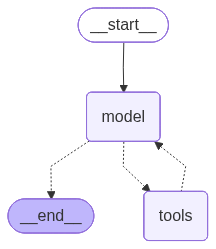

In [7]:
agentWithTool = create_agent(
    model= ChatGroq(api_key=groq_api_key, model="openai/gpt-oss-120b"),
    tools=[get_weather_tool],
    system_prompt="You are a helpful assistant that provides weather information."
)
agentWithTool

Now if we see the above diagram we have created an agent with a tool to get weather information

In [8]:
response = agentWithTool.invoke({"message": "what is the weather in New York?"})
response

{'messages': [AIMessage(content='Sure! I can look up the current weather for you. Could you let me know which city or location you’re interested in?', additional_kwargs={'reasoning_content': "The user wants weather info. We need to ask location? The user hasn't provided location. We can ask for location. Probably respond asking for location."}, response_metadata={'token_usage': {'completion_tokens': 66, 'prompt_tokens': 135, 'total_tokens': 201, 'completion_time': 0.140081992, 'completion_tokens_details': {'reasoning_tokens': 31}, 'prompt_time': 0.012765762, 'prompt_tokens_details': None, 'queue_time': 0.206317518, 'total_time': 0.152847754}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_5a93aea882', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019c2cca-4f29-7661-b9b5-193efc00dd36-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 135, 'output_tokens': 66, 'total_tokens': 201, 'out